In [1]:
#====================================================================================================#
#                                                                                                    #
#                                                        ██╗   ██╗   ████████╗ █████╗ ██████╗        #
#      Modelo Baseline Examen Final - INAR               ██║   ██║   ╚══██╔══╝██╔══██╗██╔══██╗       #
#                                                        ██║   ██║█████╗██║   ███████║██║  ██║       #
#      created:        15/01/2026  -  01:04:30           ██║   ██║╚════╝██║   ██╔══██║██║  ██║       #
#      last change:    05/02/2026  -  10:11:23           ╚██████╔╝      ██║   ██║  ██║██████╔╝       #
#                                                         ╚═════╝       ╚═╝   ╚═╝  ╚═╝╚═════╝        #
#                                                                                                    #
#      Ismael Hernandez Clemente                         ismael.hernandez@live.u-tad.com             #
#                                                                                                    #
#      Github:                                           https://github.com/ismaelucky342            #
#                                                                                                    #
#====================================================================================================# 

# Modelo Final - Fashion-MNIST



## Carga de datos

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

2026-02-05 09:54:58.013841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770285298.182037      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770285298.235404      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770285298.617070      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770285298.617113      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770285298.617115      55 computation_placer.cc:177] computation placer alr

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)


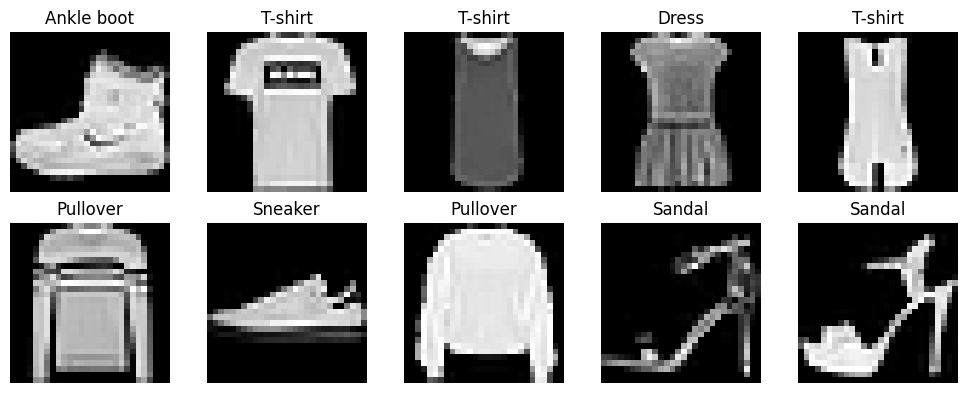

In [3]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preprocesado

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

Train: (51000, 28, 28, 1), Val: (9000, 28, 28, 1), Test: (10000, 28, 28, 1)


## Definición del modelo

In [5]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770285311.801577      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

## Entrenamiento

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
]

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=40,
    validation_data=(x_val, y_val_cat),
    callbacks=callbacks
)

Epoch 1/40


I0000 00:00:1770285316.719396     118 service.cc:152] XLA service 0x783ebc016850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770285316.719431     118 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770285317.397062     118 cuda_dnn.cc:529] Loaded cuDNN version 91002


 24/399 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5097 - loss: 1.6942

I0000 00:00:1770285322.515504     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


399/399 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7659 - loss: 0.7075 - val_accuracy: 0.6256 - val_loss: 1.0019 - learning_rate: 0.0010
Epoch 2/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8810 - loss: 0.3302 - val_accuracy: 0.9054 - val_loss: 0.2607 - learning_rate: 0.0010
Epoch 3/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9026 - loss: 0.2673 - val_accuracy: 0.9029 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 4/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9095 - loss: 0.2482 - val_accuracy: 0.9159 - val_loss: 0.2356 - learning_rate: 0.0010
Epoch 5/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9173 - loss: 0.2287 - val_accuracy: 0.9218 - val_loss: 0.2125 - learning_rate: 0.0010
Epoch 6/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9249 - loss: 0.2049 - val_accuracy: 0.9256 - val_loss: 0.2019 - learning_rate: 0.0010
Epoch 7/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9303 - loss: 0.1897 - val_accur

## Resultados en validación

In [7]:
train_loss = history.history['loss'][-1]
train_acc = history.history['accuracy'][-1]
val_loss = history.history['val_loss'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\nTrain - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


Train - Loss: 0.0544, Acc: 0.9795
Val   - Loss: 0.1858, Acc: 0.9486


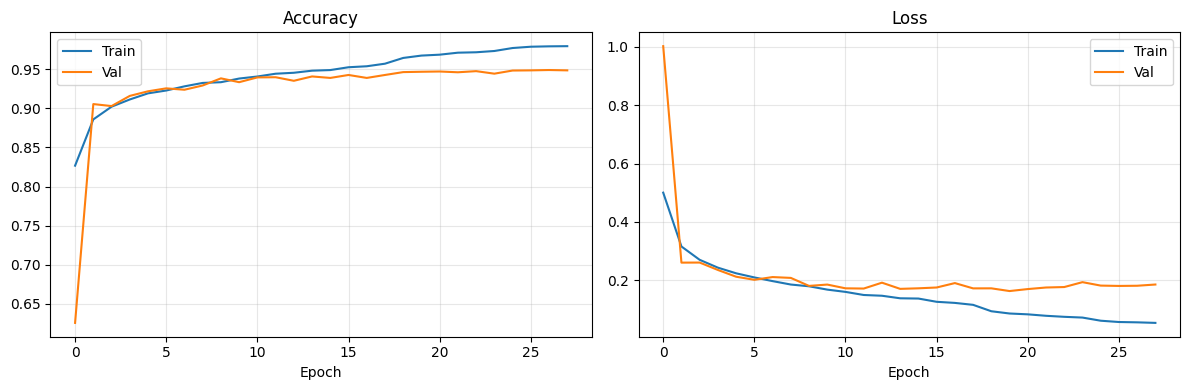

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluación final

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"\nTest - Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")


Test - Loss: 0.1926, Acc: 0.9384


### Matriz de confusión

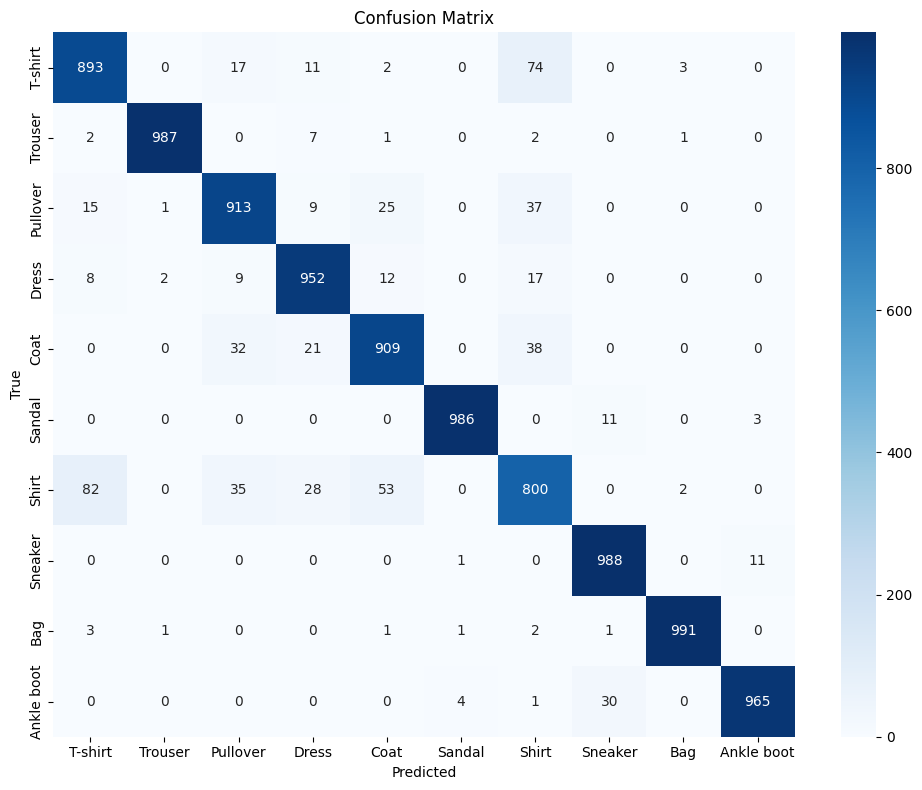

In [10]:
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

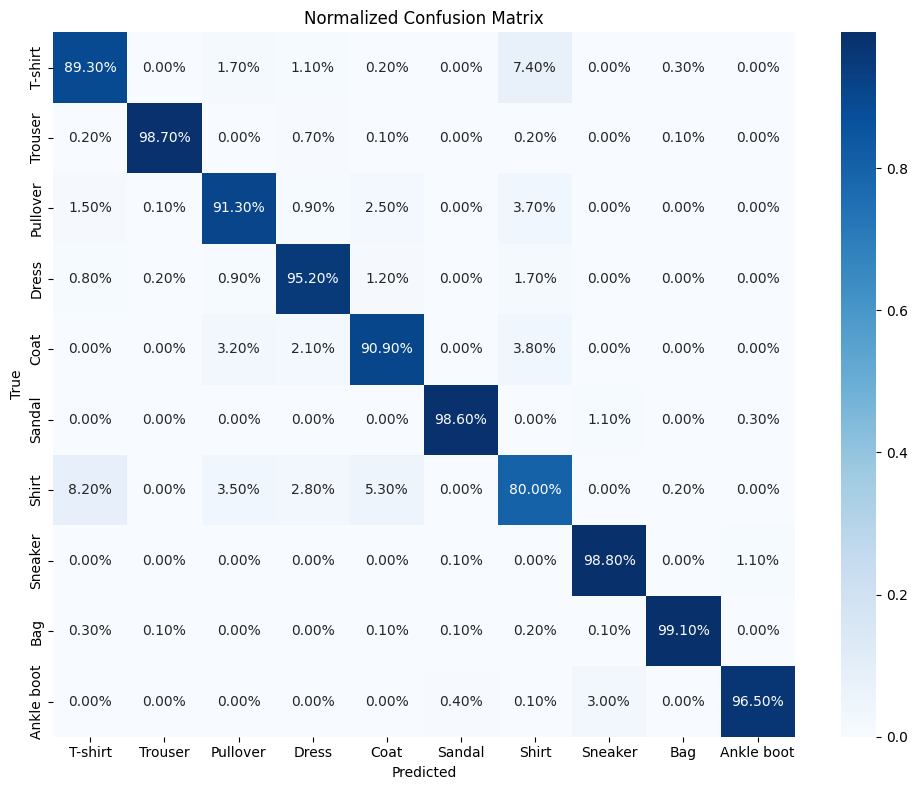

In [11]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [12]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

     T-shirt       0.89      0.89      0.89      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.91      0.91      0.91      1000
       Dress       0.93      0.95      0.94      1000
        Coat       0.91      0.91      0.91      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.82      0.80      0.81      1000
     Sneaker       0.96      0.99      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.96      0.98      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



### Ejemplos de predicciones

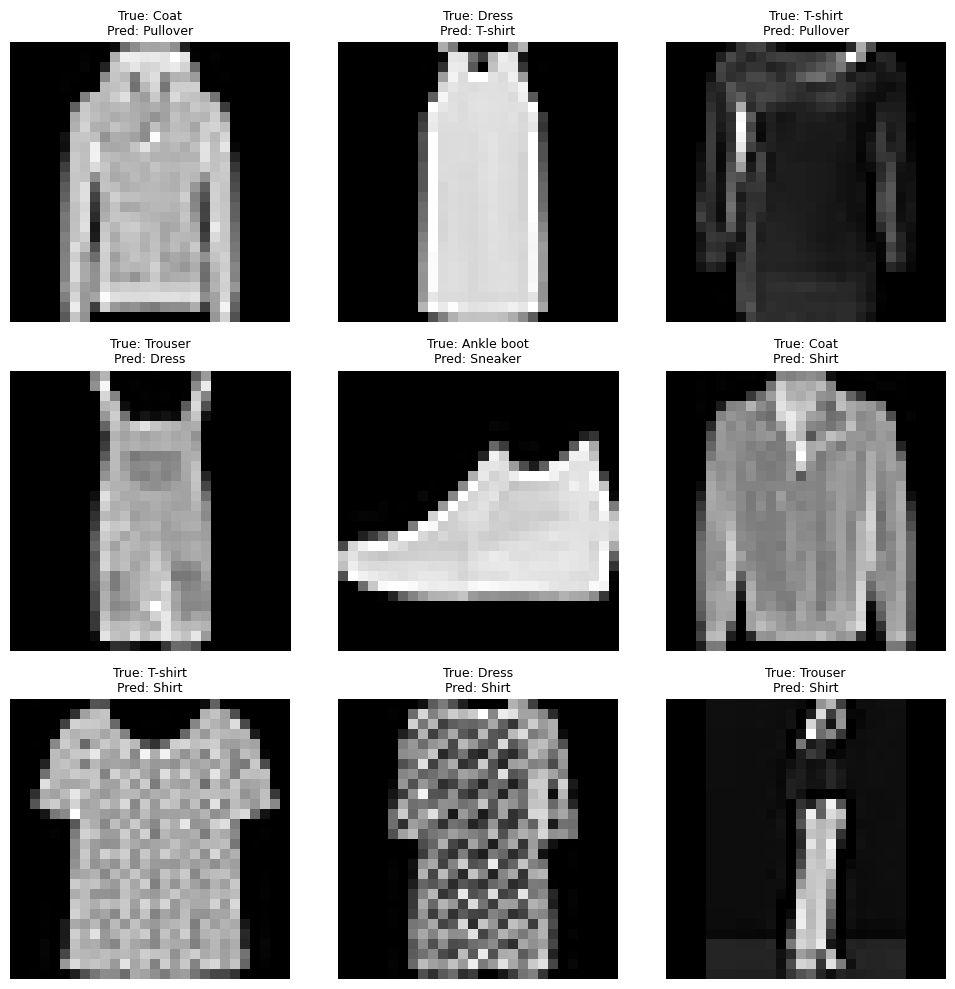

In [13]:
incorrect = np.where(y_pred_classes != y_test)[0]
sample = np.random.choice(incorrect, 9, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(sample):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    plt.title(f'True: {true_label}\nPred: {pred_label}', fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusión final e implementaciones

El modelo baseline de este modelo actual constaba de una CNN sencilla con dos bloques convolucionales simples y una capa densa de 128 neuronas. Aunque funcionaba correctamente, estaban claras varias áreas de mejora que podrían aumentar su rendimiento.

He decidido para este modelo final profundizar la arquitectura añadiendo una segunda capa convolucional en cada bloque, lo que permite al modelo aprender características más ricas y complejas de las imágenes de Fashion-MNIST. Para estabilizar este entrenamiento más profundo, he incorporado BatchNormalization después de cada capa convolucional y en la capa densa, lo que acelera la convergencia y mejora la estabilidad del modelo.

Totalmente consciente del riesgo de overfitting con una red más profunda, he implementado regularización mediante Dropout 0.25 después de cada bloque convolucional y 0.5 antes de la capa de salida. Además, he utilizado padding='same' en las convoluciones para no perder información en los bordes de las imágenes, y he aumentado las neuronas de la capa densa a 256 para darle mayor capacidad de representación.

Para optimizar el proceso de entrenamiento, he incorporado dos callbacks que veo fundamentales EarlyStopping con paciencia de 8 épocas para evitar entrenamientos innecesarios cuando el modelo deje de mejorar, y ReduceLROnPlateau con paciencia de 4 épocas para ajustar dinámicamente el learning rate cuando el modelo se estanque. Esto me ha permitido aumentar el número de épocas a 40 sin preocuparme demasiado por el overfitting ya que los mecanismos de regularización y los callbacks trabajan juntos para mantener un buen equilibrio.

Los resultados obtenidos en el conjunto de test, junto con la matriz de confusión y el análisis de errores, demuestran que estas mejoras han sido considero que bastante efectivas. A mi parecer este modelo representa el mejor equilibrio posible entre complejidad, rendimiento y generalización dentro de las restricciones del examen, sin recurrir a Transfer Learning ni Data Augmentation.